In [ ]:
# Import Library

# Load Dataset
import pandas as pd

# Preprocessing Text
!pip install sastrawi
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from tqdm import tqdm
tqdm.pandas()

# Pelabelan
import requests
import matplotlib.pyplot as plt

# Eksplorasi Label
from wordcloud import WordCloud

# Data Splitting dan Ekstraksi Fitur dengan TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Model SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC

# Model RF
from sklearn.ensemble import RandomForestClassifier

# Model LR
from sklearn.linear_model import LogisticRegression

# Model Gru
!pip install --upgrade gensim==4.3.2 scipy==1.12.0
import numpy as np
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Menyimpan Model
import joblib

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Load Dataset
df = pd.read_csv("tokopedia_reviews.csv")

## Exploratory Data Analysis (EDA)

In [ ]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,48a1c545-8603-4e39-9b8c-aa6256e7c75c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kurir rekomendasi, tp aslinya sangt tidak dire...",1,0,NaN,2025-10-12 14:27:07,NaN,NaN,NaN
1,bf504b7e-8989-4ca4-a799-e9cd8290704b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,3.333.0,2025-10-12 13:58:40,NaN,NaN,3.333.0
2,e3aba066-b54f-48cd-a427-59817f2e36c7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ga tau kenapa.. dengan tokopedia sekarang laya...,1,1,3.333.0,2025-10-12 13:42:39,NaN,NaN,3.333.0
3,2071734e-cad6-4567-b7cf-768b4aa50177,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"pelayanan kirim lama sekali, respon penjual ju...",1,0,3.333.0,2025-10-12 13:19:14,NaN,NaN,3.333.0
4,2234d90c-00a1-437b-a022-fc409479a1f3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sumpah yesal gua Makai apk ini pesanan gak ada...,1,0,3.333.0,2025-10-12 13:10:12,NaN,NaN,3.333.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              30000 non-null  object
 1   userName              30000 non-null  object
 2   userImage             30000 non-null  object
 3   content               29999 non-null  object
 4   score                 30000 non-null  int64 
 5   thumbsUpCount         30000 non-null  int64 
 6   reviewCreatedVersion  23631 non-null  object
 7   at                    30000 non-null  object
 8   replyContent          15245 non-null  object
 9   repliedAt             15245 non-null  object
 10  appVersion            23631 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.5+ MB


In [ ]:
clean_df = df.copy()
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN)
clean_df = clean_df.dropna()
# Menghapus baris duplikat
clean_df = clean_df.drop_duplicates()
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape
print("Jumlah ulasan bersih:", jumlah_ulasan_setelah_hapus_duplikat)
print("Jumlah kolom:", jumlah_kolom_setelah_hapus_duplikat)


Jumlah ulasan bersih: 12085
Jumlah kolom: 11


In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12085 entries, 18 to 29999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              12085 non-null  object
 1   userName              12085 non-null  object
 2   userImage             12085 non-null  object
 3   content               12085 non-null  object
 4   score                 12085 non-null  int64 
 5   thumbsUpCount         12085 non-null  int64 
 6   reviewCreatedVersion  12085 non-null  object
 7   at                    12085 non-null  object
 8   replyContent          12085 non-null  object
 9   repliedAt             12085 non-null  object
 10  appVersion            12085 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.1+ MB


## Preprocessing Text

In [ ]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    if isinstance(text, list):
        words = text
    else:
        words = str(text).split()

    stemmed_words = [stemmer.stem(word) for word in words]
    return stemmed_words

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [ ]:
slangwords = {
    "bgs": "bagus", "bget": "banget", "bgtt": "banget", "bgt": "banget", "mantul": "mantap", "bagu": "bagus", "yg": "yang",
    "rekomen": "rekomendasi", "recom": "rekomendasi", "worthit": "layak", "fix": "pasti", "top": "bagus",
    "kece": "bagus", "mantab": "mantap", "mantabb": "mantap", "oke": "baik", "okee": "baik", "oke banget": "sangat bagus",
    "lumayan": "cukup bagus", "oke lah": "baik", "meh": "biasa saja", "ampun dah": "tidak bagus",
    "jelek": "buruk", "jelek bgt": "buruk sekali", "parah": "buruk", "ancur": "rusak", "rusak bgt": "rusak parah",
    "zonk": "mengecewakan", "ngaco": "tidak masuk akal", "kecewa bgt": "sangat kecewa", "boong": "bohong",
    "ribet": "rumit", "lemot": "lambat", "slow respon": "pelayanan lambat", "delay": "terlambat",
    "fast respon": "pelayanan cepat", "respon cepat": "pelayanan cepat", "gampang": "mudah", "pas": "sesuai",
    "gk": "tidak", "ga": "tidak", "g": "tidak", "tp": "tapi", "trs": "terus", "dr": "dari", "dri": "dari",
    "sm": "sama", "sma": "sama", "jd": "jadi", "jdi": "jadi", "blm": "belum", "blom": "belum", "bs": "bisa",
    "bsa": "bisa", "klo": "kalau", "kalo": "kalau", "mksh": "terima kasih", "mks": "terima kasih", "mksih": "terima kasih",
    "tq": "terima kasih", "thx": "terima kasih", "ty": "terima kasih", "makasih": "terima kasih", "makasih ya": "terima kasih",
    "next time": "lain kali",
    "udh": "sudah", "udah": "sudah", "ud": "sudah", "uda": "sudah", "lma": "lama", "lamaa": "lama", "lmbt": "lambat",
    "smpe": "sampai", "sampe": "sampai", "nyampe": "sampai", "nyasar": "tersesat", "telat": "terlambat",
    "kyk": "seperti", "ky": "seperti", "gini": "begini", "gt": "begitu", "gtu": "begitu", "ni": "ini",
    "nih": "ini", "tu": "itu", "tuh": "itu", "pesen": "pesan", "psen": "pesan", "bnyk": "banyak", "bny": "banyak",
    "app": "aplikasi", "apk": "aplikasi", "lag": "lambat", "bug": "kesalahan sistem", "error": "kesalahan",
    "notif": "notifikasi", "fitur": "fitur aplikasi", "cs": "customer service", "kurir": "pengirim", "tokped": "tokopedia", "toped": "tokopedia",
    "astaga": "mengejutkan", "yah": "sayang sekali", "duh": "sayang sekali"}

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [ ]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].progress_apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].progress_apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].progress_apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].progress_apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].progress_apply(filteringText)

# Melakukan stemming pada kalimat untuk mendapatkan kata dasar
clean_df['text_stemming'] = clean_df['text_stopword'].progress_apply(stemmingText)

# Menyimpan hasil akhir ke kolom 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stemming'].progress_apply(toSentence)

100%|██████████| 12085/12085 [00:00<00:00, 387349.47it/s]


In [ ]:
clean_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_stemming,text_akhir
18,c9f7827d-6dd5-4d97-bb1a-f89a8ad7dd8c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Makin kesini makin banyak eror Nyoba instal ul...,1,1,3.332.0,2025-10-12 09:57:49,"Toppers, mohon maaf atas kendala yang kamu ala...",2025-03-20 23:20:08,3.332.0,Makin kesini makin banyak eror Nyoba instal ul...,makin kesini makin banyak eror nyoba instal ul...,makin kesini makin banyak eror nyoba instal ul...,"[makin, kesini, makin, banyak, eror, nyoba, in...","[kesini, eror, nyoba, instal, ulang, nunggu, g...","[kesini, eror, nyoba, instal, ulang, nunggu, g...",kesini eror nyoba instal ulang nunggu gagal in...
71,ad5a3ad8-fd81-4a46-b4d5-c025f585a8ae,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kagak enak belanja di toped, gak bebas belanja...",1,1,3.333.0,2025-10-11 15:11:32,"Toppers, mohon maaf atas kendala yang kamu ala...",2024-10-29 02:40:12,3.333.0,kagak enak belanja di toped gak bebas belanja ...,kagak enak belanja di toped gak bebas belanja ...,kagak enak belanja di tokopedia gak bebas bela...,"[kagak, enak, belanja, di, tokopedia, gak, beb...","[kagak, enak, belanja, tokopedia, bebas, belan...","[kagak, enak, belanja, tokopedia, bebas, belan...",kagak enak belanja tokopedia bebas belanja uni...
91,c7b4ef69-f102-4597-9b5d-da59634bb87c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Update : Makin kecewa, di sisi sebagai seller ...",1,49,3.333.0,2025-10-11 10:19:29,"Hi Toppers, silakan sampaikan kritik/saran ata...",2024-10-10 12:20:09,3.333.0,Update Makin kecewa di sisi sebagai seller ma...,update makin kecewa di sisi sebagai seller ma...,update makin kecewa di sisi sebagai seller mak...,"[update, makin, kecewa, di, sisi, sebagai, sel...","[update, kecewa, sisi, seller, adminnya, otoma...","[update, kecewa, sisi, seller, adminnya, otoma...",update kecewa sisi seller adminnya otomatis pa...
93,021ef063-1250-4255-8ed6-7874a26b90f3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Saya beli barang di tokped di cancel penjual g...,1,0,3.333.0,2025-10-11 09:42:48,Hai Kak Riza. Maaf atas ketidaknyamanannya ya....,2020-12-13 13:28:12,3.333.0,Saya beli barang di tokped di cancel penjual g...,saya beli barang di tokped di cancel penjual g...,saya beli barang di tokopedia di cancel penjua...,"[saya, beli, barang, di, tokopedia, di, cancel...","[beli, barang, tokopedia, cancel, penjual, gar...","[beli, barang, tokopedia, cancel, jual, gara, ...",beli barang tokopedia cancel jual gara gara be...
100,629d902e-02e7-4acd-8b50-adc603d606a9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi ini mulai ada perbaikan,5,0,3.333.0,2025-10-11 07:52:49,"Hai Frandy, terima kasih atas review yg kamu b...",2019-11-23 08:07:22,3.333.0,Aplikasi ini mulai ada perbaikan,aplikasi ini mulai ada perbaikan,aplikasi ini mulai ada perbaikan,"[aplikasi, ini, mulai, ada, perbaikan]","[aplikasi, perbaikan]","[aplikasi, baik]",aplikasi baik


## Pelabelan

In [ ]:
def load_lexicon(source_url):
    response = requests.get(source_url)
    if response.status_code == 200:
        word_set = {line.strip() for line in response.text.splitlines() if line.strip()}
        return word_set
    else:
        print(f"Unable to retrieve data from {source_url} (status code: {response.status_code})")
        return set()

lexicon_links = {
    "positive": "https://raw.githubusercontent.com/masdevid/ID-OpinionWords/master/positive.txt",
    "negative": "https://raw.githubusercontent.com/masdevid/ID-OpinionWords/master/negative.txt"
}

lexicon_data = {label: load_lexicon(url) for label, url in lexicon_links.items()}

for label, word_list in lexicon_data.items():
    print(f"Total {label} words: {len(word_list)}")

Total positive words: 1182
Total negative words: 2402


In [ ]:
def analyze_sentiment(tokens):
    score = sum(
        (1 if word in lexicon_data["positive"] else
         -1 if word in lexicon_data["negative"] else 0)
        for word in tokens
    )

    sentiment = "positive" if score > 0 else "negative" if score < 0 else "neutral"
    return score, sentiment

In [ ]:
results = clean_df['text_stemming'].apply(analyze_sentiment)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
neutral     5820
positive    4272
negative    1993
Name: count, dtype: int64


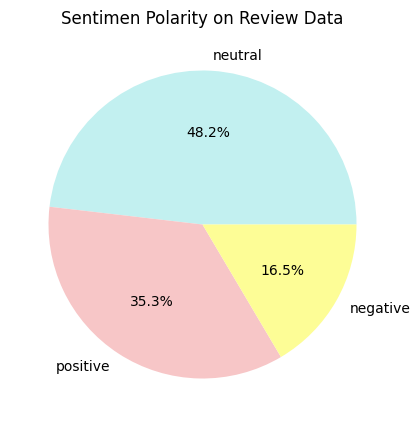

In [ ]:
colors = ['#c2f0f0', '#f7c6c7', '#fdfd96']

clean_df['polarity'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(5,5),
    title='Sentimen Polarity on Review Data',
    ylabel='',
    colors=colors
)
plt.show()

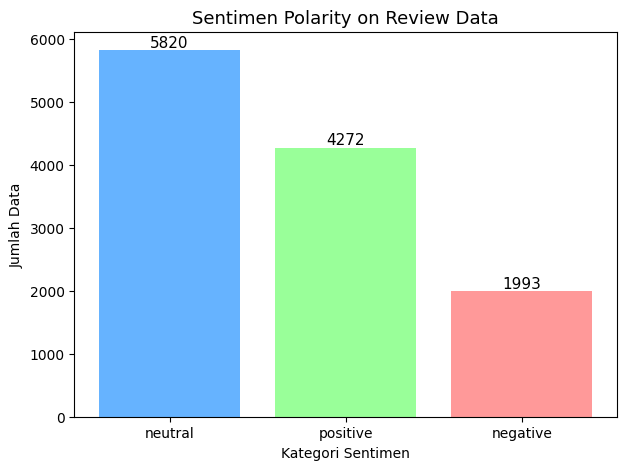

In [ ]:
sentiment_counts = clean_df['polarity'].value_counts()

plt.figure(figsize=(7,5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['#66b3ff', '#99ff99', '#ff9999'])

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height()}',
        ha='center', va='bottom', fontsize=11
    )

plt.title('Sentimen Polarity on Review Data', fontsize=13)
plt.xlabel('Kategori Sentimen', fontsize=10)
plt.ylabel('Jumlah Data', fontsize=10)

plt.show()

## Eksplorasi Label

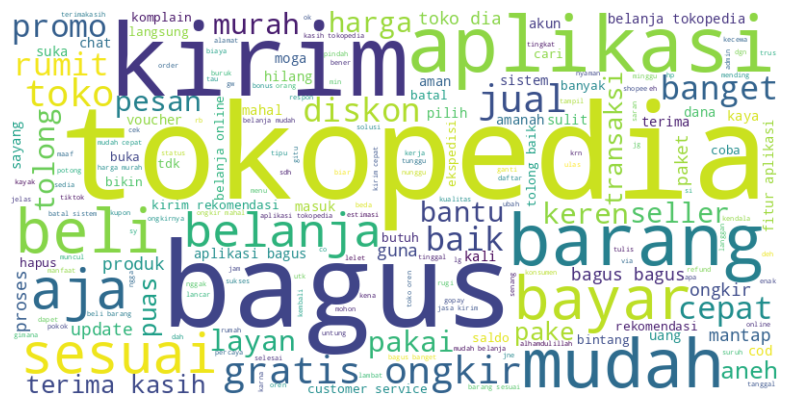

In [ ]:
# Gabungkan semua teks dengan polarity positive
positive_text = " ".join(
    clean_df[clean_df['polarity'] == 'positive']['text_akhir']
)

# Buat WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

# Tampilkan WordCloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


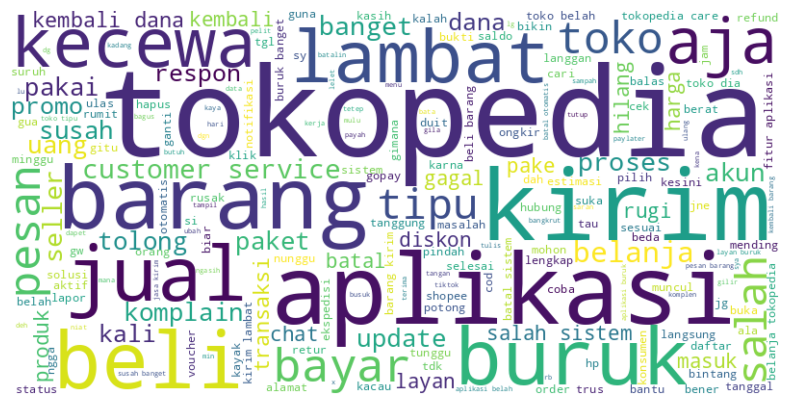

In [ ]:
# Gabungkan semua teks dengan polarity negative
negative_text = " ".join(
    clean_df[clean_df['polarity'] == 'negative']['text_akhir']
)

# Buat WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

# Tampilkan WordCloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

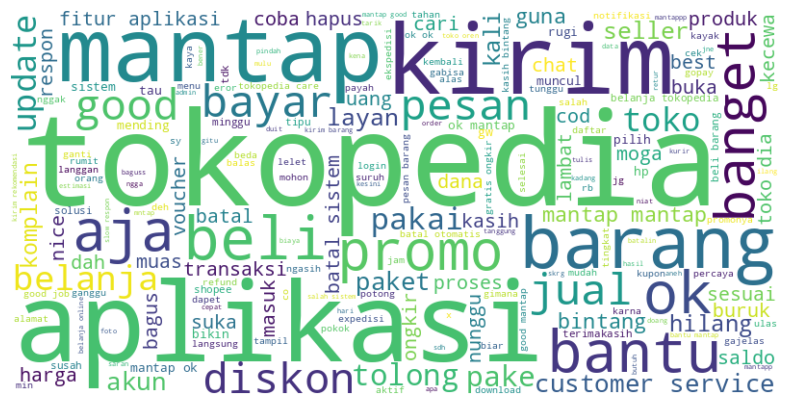

In [ ]:
# Gabungkan semua teks dengan polarity neutral
neutral_text = " ".join(
    clean_df[clean_df['polarity'] == 'neutral']['text_akhir']
)

# Buat WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(neutral_text)

# Tampilkan WordCloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

## Data Splitting dan Ekstraksi Fitur dengan TF-IDF

In [ ]:
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir'].astype(str)
y = clean_df['polarity'].map(label_map)

# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=5000, min_df=3, max_df=0.9)
X_tfidf = tfidf.fit_transform(X)

## Model

### Support Vector Machines (TF-IDF)

In [ ]:
# Bagi data menjadi data latih dan data uji
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [ ]:
svm = SVC(
    kernel='linear',
    C=3.0,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)

# Latih model
svm.fit(X_train_svm, y_train_svm)

# Prediksi
y_pred_train_svm = svm.predict(X_train_svm)
y_pred_test_svm = svm.predict(X_test_svm)

# Evaluasi
accuracy_train_svm = accuracy_score(y_train_svm, y_pred_train_svm)
accuracy_test_svm = accuracy_score(y_test_svm, y_pred_test_svm)

print(f"SVM - accuracy_train: {accuracy_train_svm:.4f}")
print(f"SVM - accuracy_test: {accuracy_test_svm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_svm, y_pred_test_svm))

SVM - accuracy_train: 0.9851
SVM - accuracy_test: 0.9268

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.88       400
           1       0.92      0.93      0.93      1123
           2       0.97      0.93      0.95       894

    accuracy                           0.93      2417
   macro avg       0.91      0.92      0.92      2417
weighted avg       0.93      0.93      0.93      2417



### Random Forest (TF-IDF)

In [ ]:
# Bagi data menjadi data latih dan data uji
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [ ]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

random_forest.fit(X_train_rf, y_train_rf)

y_pred_train_rf = random_forest.predict(X_train_rf)
y_pred_test_rf = random_forest.predict(X_test_rf)

accuracy_train_rf = accuracy_score(y_train_rf, y_pred_train_rf)
accuracy_test_rf = accuracy_score(y_test_rf, y_pred_test_rf)

print(f"Random Forest - accuracy_train: {accuracy_train_rf:.4f}")
print(f"Random Forest - accuracy_test: {accuracy_test_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_rf, y_pred_test_rf))

Random Forest - accuracy_train: 0.9994
Random Forest - accuracy_test: 0.8647

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.78      0.76       400
           1       0.87      0.89      0.88      1123
           2       0.92      0.87      0.89       894

    accuracy                           0.86      2417
   macro avg       0.84      0.85      0.85      2417
weighted avg       0.87      0.86      0.87      2417



### Logistic Regression (TF-IDF)

In [ ]:
# Bagi data menjadi data latih dan data uji
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [ ]:
logistic_regression = LogisticRegression(
    max_iter=2000,
    random_state=42,
    C=2.0,
    class_weight='balanced',
    solver='liblinear'
)

logistic_regression.fit(X_train_lr, y_train_lr)

y_pred_train_lr = logistic_regression.predict(X_train_lr)
y_pred_test_lr = logistic_regression.predict(X_test_lr)

accuracy_train_lr = accuracy_score(y_train_lr, y_pred_train_lr)
accuracy_test_lr = accuracy_score(y_test_lr, y_pred_test_lr)

print(f"Logistic Regression - accuracy_train: {accuracy_train_lr:.4f}")
print(f"Logistic Regression - accuracy_test: {accuracy_test_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_lr, y_pred_test_lr))

Logistic Regression - accuracy_train: 0.9389
Logistic Regression - accuracy_test: 0.8891

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       400
           1       0.88      0.89      0.88      1123
           2       0.95      0.90      0.92       894

    accuracy                           0.89      2417
   macro avg       0.87      0.89      0.88      2417
weighted avg       0.89      0.89      0.89      2417



### GRU (Word2Vec)

In [54]:
# Tokenizing + Padding
tokenizer = Tokenizer(num_words=20000, oov_token='OOV')
tokenizer.fit_on_texts(X)
X_seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(X_seq, maxlen=100)
word_index = tokenizer.word_index

# Split Data
X_train_gru, X_test_gru, y_train_gru, y_test_gru = train_test_split(X_pad, y, test_size=0.2, random_state=42)
X_train_gru, X_val_gru, y_train_gru, y_val_gru = train_test_split(X_train_gru, y_train_gru, test_size=0.125, random_state=42)

# Train Word2Vec
sentences = [text.split() for text in X]
w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)
embedding_dim = 100

# Embedding Matrix
num_words = min(20000, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))
for word, i in word_index.items():
    if i < num_words and word in w2v.wv:
        embedding_matrix[i] = w2v.wv[word]

# GRU Model
gru_model = Sequential([
    Embedding(num_words, embedding_dim, weights=[embedding_matrix], trainable=True),
    SpatialDropout1D(0.3),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.4),
    GRU(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

# Compile Model
gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=5e-4),
    metrics=['accuracy']
)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy', patience=3, restore_best_weights=True, min_delta=0.001, mode='max'
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6
)
callbacks = [early_stopping, reduce_lr]

# Train Model
history = gru_model.fit(
    X_train_gru, y_train_gru,
    validation_data=(X_val_gru, y_val_gru),
    epochs=25,
    batch_size=64,
    verbose=1,
    callbacks=callbacks
)

# Evaluate Model
test_loss_gru, test_acc_gru = gru_model.evaluate(X_test_gru, y_test_gru, verbose=0)
print(f"\nTest Accuracy: {test_acc_gru:.4f}")
print(f"Test Loss: {test_loss_gru:.4f}")

# Predict
y_pred_gru = np.argmax(gru_model.predict(X_test_gru), axis=1)
print("\nClassification Report:")
print(classification_report(y_test_gru, y_pred_gru))

Epoch 1/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 98s 649ms/step - accuracy: 0.5206 - loss: 0.9496 - val_accuracy: 0.6758 - val_loss: 0.6915 - learning_rate: 5.0000e-04
Epoch 2/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 86s 643ms/step - accuracy: 0.7021 - loss: 0.6485 - val_accuracy: 0.7767 - val_loss: 0.4976 - learning_rate: 5.0000e-04
Epoch 3/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 140s 634ms/step - accuracy: 0.7890 - loss: 0.4785 - val_accuracy: 0.8213 - val_loss: 0.4135 - learning_rate: 5.0000e-04
Epoch 4/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 144s 648ms/step - accuracy: 0.8560 - loss: 0.3566 - val_accuracy: 0.8652 - val_loss: 0.3414 - learning_rate: 5.0000e-04
Epoch 5/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 144s 662ms/step - accuracy: 0.9099 - loss: 0.2222 - val_accuracy: 0.8933 - val_loss: 0.2598 - learning_rate: 5.0000e-04
Epoch 6/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 138s 634ms/step - accuracy: 0.9461 - loss: 0.1346 - val_accuracy: 0.8999 - val_loss: 0.2421 - learning_rate: 5.0000e-04
Epoch 7/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 86

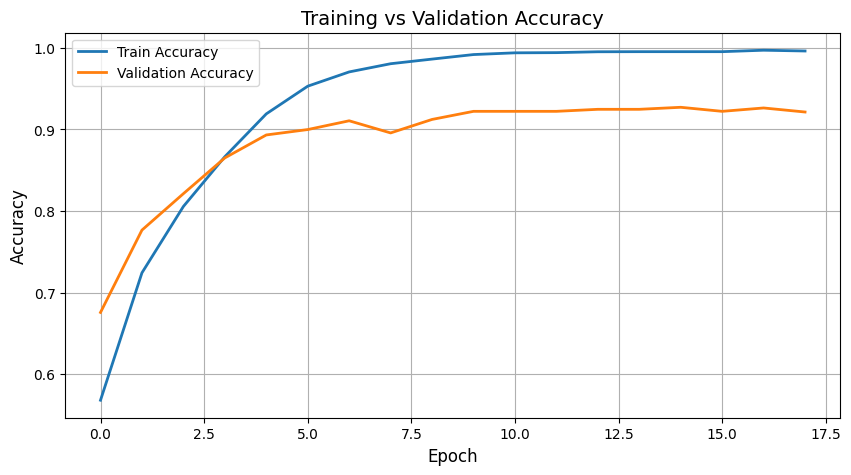

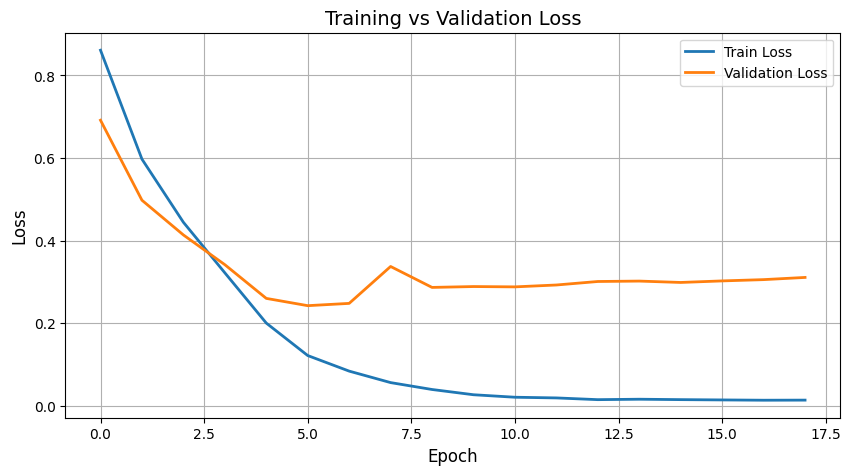

In [61]:
# Plot Accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Training vs Validation Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [62]:
df_accuracy = pd.DataFrame({
    'Model': ['SVM', 'Random Forest', 'Logistic Regression', 'Gru'],
    'Accuracy': [
        f"{accuracy_test_svm:.2%}",
        f"{accuracy_test_rf:.2%}",
        f"{accuracy_test_lr:.2%}",
        f"{test_acc_gru:.2%}"
    ]
})

df_accuracy

,Model,Accuracy
0,SVM,92.68%
1,Random Forest,86.47%
2,Logistic Regression,88.91%
3,Gru,92.59%


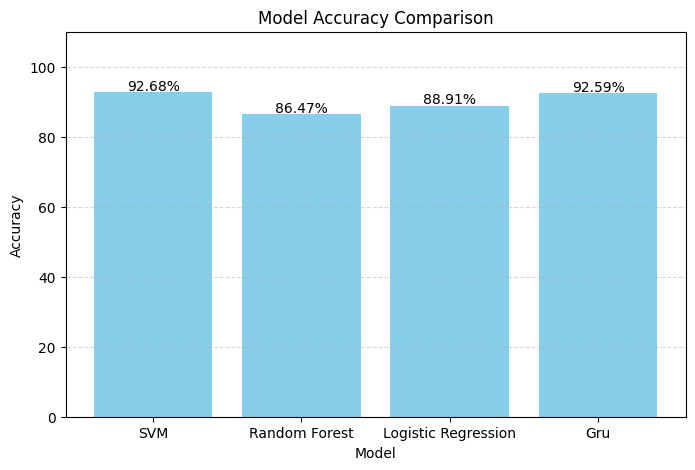

In [63]:
df_accuracy['Accuracy_float'] = df_accuracy['Accuracy'].str.rstrip('%').astype(float)

plt.figure(figsize=(8, 5))
plt.bar(df_accuracy['Model'], df_accuracy['Accuracy_float'], color='skyblue')

# Label di atas bar
for i, v in enumerate(df_accuracy['Accuracy_float']):
    plt.text(i, v + 0.5, f'{v:.2f}%', ha='center')

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


### Menyimpan Model

In [64]:
# Simpan model ke file
joblib.dump(svm, "svm_model.pkl")
joblib.dump(random_forest, "random_forest_model.pkl")
joblib.dump(logistic_regression, "logistic_regression_model.pkl")
gru_model.save("gru_model.h5")

# Simpan vektorizer TF-IDF
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Simpan tokenizer
tokenizer_json = tokenizer.to_json()
with open("tokenizer.json", "w") as f:
    f.write(tokenizer_json)

## File requirements.txt

In [65]:
!pip freeze > requirements.txt

## Kesimpulan

- Jika fokus utama adalah akurasi maksimum dengan representasi TF-IDF, SVM menjadi pilihan terbaik.

- Jika konteks dan urutan kata lebih penting, terutama pada teks panjang atau kompleks, GRU dengan Word2Vec lebih sesuai meskipun akurasinya sedikit lebih rendah.

- Logistic Regression dan Random Forest masih layak digunakan, tetapi performanya lebih rendah dibanding SVM dan GRU pada dataset ini.